# LAB #08 — Content-Based Image Retrieval (CBIR)


---
## Code 1: Extract and Compare Color Histograms
**Scenario:** A digital art museum CBIR system that retrieves similar artworks using color histogram correlation.


/tmp/ipykernel_28203/989198243.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Dataset ready.


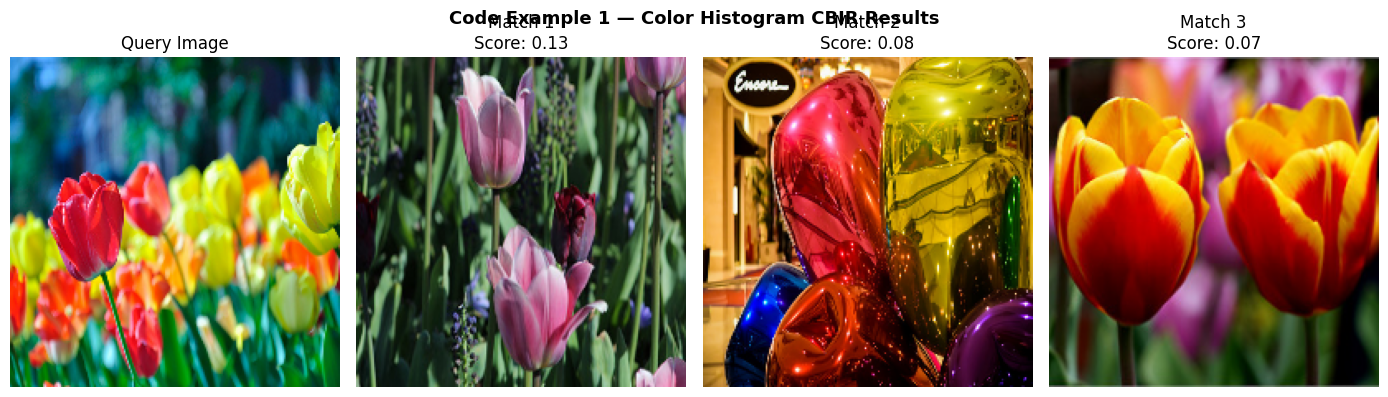

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import tarfile
import os

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
print("Downloading flower photo dataset...")
urllib.request.urlretrieve(url, "flower_photos.tgz")
with tarfile.open("flower_photos.tgz") as tar:
    tar.extractall(".")
print("Dataset ready.")

all_images = []
for root, _, files_list in os.walk("flower_photos"):
    for f in files_list:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))

query_path = all_images[0]
dataset_paths = all_images[1:21]

def get_histogram(img):
    hist = cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

query = cv2.resize(cv2.imread(query_path), (200, 200))
query_hist = get_histogram(query)

scores = []
for path in dataset_paths:
    img = cv2.imread(path)
    if img is None:
        continue
    img = cv2.resize(img, (200, 200))
    score = cv2.compareHist(query_hist, get_histogram(img), cv2.HISTCMP_CORREL)
    scores.append((score, path, img))

scores.sort(reverse=True)
top_matches = scores[:3]

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(query, cv2.COLOR_BGR2RGB))
plt.title("Query Image")
plt.axis('off')

for i, (score, fname, img) in enumerate(top_matches):
    plt.subplot(1, 4, i + 2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Match {i+1}\nScore: {score:.2f}")
    plt.axis('off')

plt.suptitle("Code Example 1 — Color Histogram CBIR Results", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Code Example 2: Wildlife Image Retrieval using Color-Based Content Analysis
**Scenario:** A wildlife research center retrieves visually similar tiger images using HSV color histograms and cosine similarity.



Downloaded: tiger.jpg
Failed to download tp.jpg: HTTP Error 400: Use thumbnail sizes listed on https://w.wiki/GHai
Failed to download fc.jpg: HTTP Error 400: Use thumbnail sizes listed on https://w.wiki/GHai
Downloaded: lioness.jpg


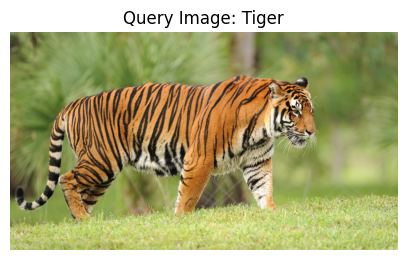

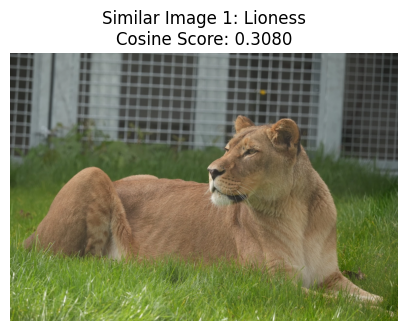

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from sklearn.metrics.pairwise import cosine_similarity

image_urls = {
    'tiger.jpg':   'https://cdn1.parksmedia.wdprapps.disney.com/resize/mwImage/1/1600/900/75/dam/wdpro-assets/parks-and-tickets/attractions/animal-kingdom/disney-animals/disney-animals-asian-sumatran-tigers/disney-animals-asian-sumatran-tigers-00.jpg?1776764215451',
    'tp.jpg':      'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Bengal_tiger_%28Panthera_tigris_tigris%29_female_3_crop.jpg/400px-Bengal_tiger_%28Panthera_tigris_tigris%29_female_3_crop.jpg',
    'fc.jpg':      'https://upload.wikimedia.org/wikipedia/commons/thumb/4/48/RedCat_8727.jpg/400px-RedCat_8727.jpg',
    'lioness.jpg': 'https://media.4-paws.org/6/d/6/4/6d647f6c7f38a1dcc8e0a480072b77ffd7181080/VIER%20PFOTEN_2024-10-16_00027-3815x2548-3300x2282-1920x1328.webp'
}

# Adding User-Agent to avoid 403 Forbidden error from Wikimedia
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Colab; ComputerVisionLab)')]
urllib.request.install_opener(opener)

for fname, url in image_urls.items():
    try:
        urllib.request.urlretrieve(url, fname)
        print(f"Downloaded: {fname}")
    except Exception as e:
        print(f"Failed to download {fname}: {e}")

def extract_color_histogram(image, bins=(8, 8, 8)):
    if image is None: return np.zeros(np.prod(bins))
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

query_img = cv2.imread('tiger.jpg')
query_features = extract_color_histogram(query_img)

dataset_files = ['tp.jpg', 'fc.jpg', 'lioness.jpg']
labels = ['Tiger Profile', 'Forest Cat', 'Lioness']

dataset = [cv2.imread(f) for f in dataset_files]
dataset_features = [extract_color_histogram(img) for img in dataset]

similarities = [cosine_similarity([query_features], [f])[0][0] for f in dataset_features]
ranked = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True)

plt.figure(figsize=(5, 5))
if query_img is not None:
    plt.imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
    plt.title('Query Image: Tiger')
    plt.axis('off')
    plt.show()

for i in range(3):
    idx = ranked[i]
    if dataset[idx] is not None:
        plt.figure(figsize=(5, 5))
        plt.imshow(cv2.cvtColor(dataset[idx], cv2.COLOR_BGR2RGB))
        plt.title(f"Similar Image {i+1}: {labels[idx]}\nCosine Score: {similarities[idx]:.4f}")
        plt.axis('off')
        plt.show()

In [ ]:
from google.colab import files
import os

print("Upload your kaggle.json file:")
files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API configured successfully.")

Upload your kaggle.json file:


Saving Kaggle.json to Kaggle.json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API configured successfully.


---
## Code Example 3: Texture-Based Defect Detection in Fabric Inspection
**Scenario:** A textile manufacturer automates quality inspection using Local Binary Pattern (LBP) texture features to detect fabric defects.

Dataset URL: https://www.kaggle.com/datasets/ag3ntsp1d3rx/kth-tips-2
License(s): unknown
KTH-TIPS-2 dataset ready.
Total texture images found: 810


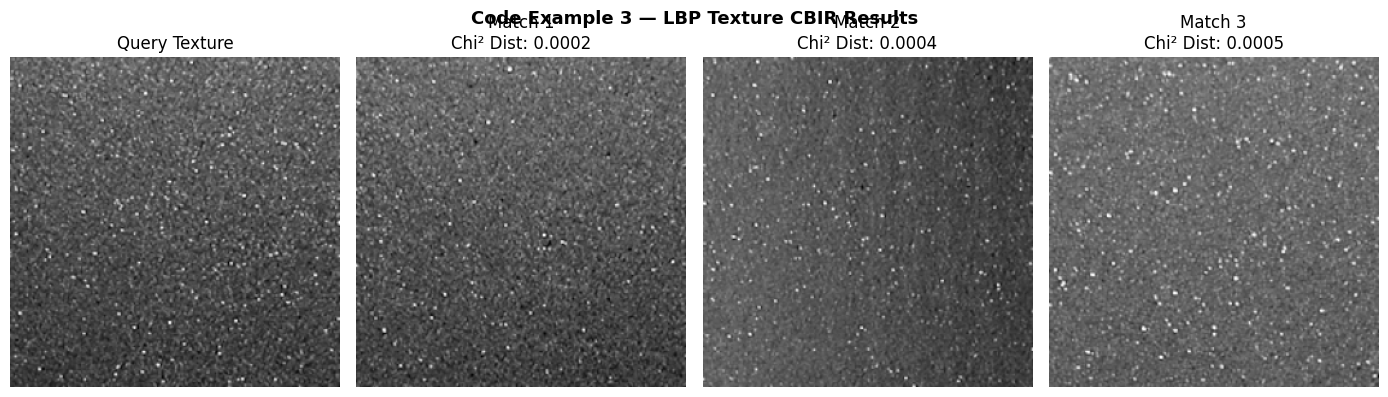

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from skimage.feature import local_binary_pattern

!kaggle datasets download -d ag3ntsp1d3rx/kth-tips-2 --quiet
with zipfile.ZipFile('kth-tips-2.zip', 'r') as z:
    z.extractall('kth_tips_2')
print("KTH-TIPS-2 dataset ready.")

all_textures = []
for root, _, files_list in os.walk('kth_tips_2'):
    for f in files_list:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_textures.append(os.path.join(root, f))

print(f"Total texture images found: {len(all_textures)}")

def extract_lbp_features(gray_img):
    lbp = local_binary_pattern(gray_img, P=24, R=3, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

def chi2_distance(histA, histB, eps=1e-6):
    return 0.5 * np.sum(((histA - histB) ** 2) / (histA + histB + eps))

query_path = all_textures[0]
dataset_paths = all_textures[1:30]

query_img = cv2.resize(cv2.imread(query_path, cv2.IMREAD_GRAYSCALE), (256, 256))
query_hist = extract_lbp_features(query_img)

scores = []
for path in dataset_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (256, 256))
    hist = extract_lbp_features(img)
    dist = chi2_distance(query_hist, hist)
    scores.append((dist, path, img))

scores.sort(key=lambda x: x[0])
top_matches = scores[:3]

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1)
plt.imshow(query_img, cmap='gray')
plt.title("Query Texture")
plt.axis('off')

for i, (dist, fname, img) in enumerate(top_matches):
    plt.subplot(1, 4, i + 2)
    plt.imshow(img, cmap='gray')
    plt.title(f"Match {i+1}\nChi² Dist: {dist:.4f}")
    plt.axis('off')

plt.suptitle("Code Example 3 — LBP Texture CBIR Results", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Case Study 1: Fashion E-Commerce Image Search
**Scenario:** An online fashion retailer enables visual product search — customers upload a clothing photo and the system finds visually similar catalog items using HSV color histogram + cosine similarity.


Dataset URL: https://www.kaggle.com/datasets/pawakapan/deepfashion
License(s): unknown
DeepFashion dataset ready.
Total fashion images found: 52712


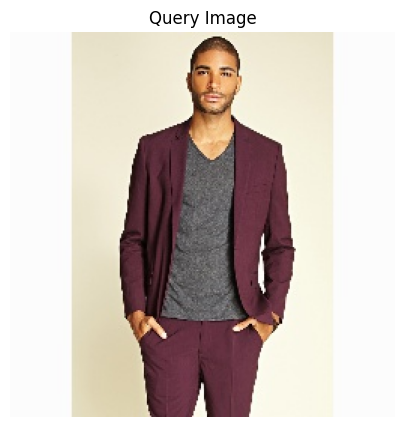

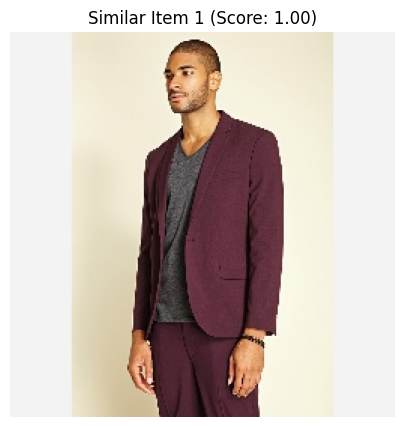

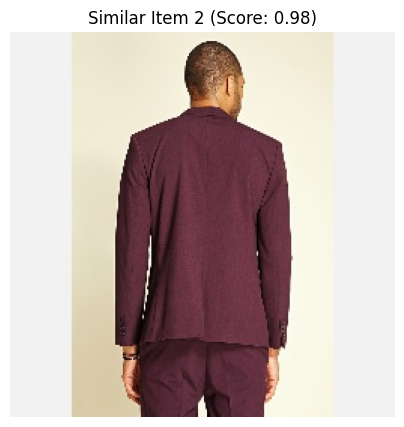

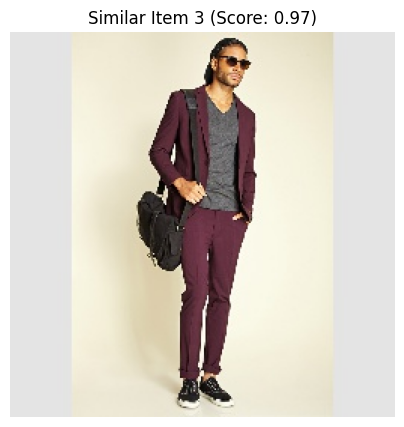

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from sklearn.metrics.pairwise import cosine_similarity

!kaggle datasets download -d pawakapan/deepfashion --quiet
with zipfile.ZipFile('deepfashion.zip', 'r') as z:
    z.extractall('deepfashion')
print("DeepFashion dataset ready.")

fashion_images = []
for root, _, files_list in os.walk('deepfashion'):
    for f in files_list:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            fashion_images.append(os.path.join(root, f))

print(f"Total fashion images found: {len(fashion_images)}")

def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

query_img = cv2.imread(fashion_images[0])
query_features = extract_color_histogram(query_img)

dataset_imgs = []
dataset_features = []
for path in fashion_images[1:51]:
    img = cv2.imread(path)
    if img is None:
        continue
    dataset_imgs.append(img)
    dataset_features.append(extract_color_histogram(img))

similarities = [cosine_similarity([query_features], [f])[0][0] for f in dataset_features]
ranked = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
plt.title('Query Image')
plt.axis('off')
plt.show()

top_k = 3
for i in range(min(top_k, len(dataset_imgs))):
    idx = ranked[i]
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(dataset_imgs[idx], cv2.COLOR_BGR2RGB))
    plt.title(f"Similar Item {i+1} (Score: {similarities[idx]:.2f})")
    plt.axis('off')
    plt.show()

---
## Case Study 2: Medical Imaging Systems
**Scenario:** Radiologists retrieve visually similar past MRI/X-ray scans to assist diagnosis and treatment planning, using grayscale histogram features and cosine similarity.


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
Brain Tumor MRI dataset ready.
Total MRI images found: 7200


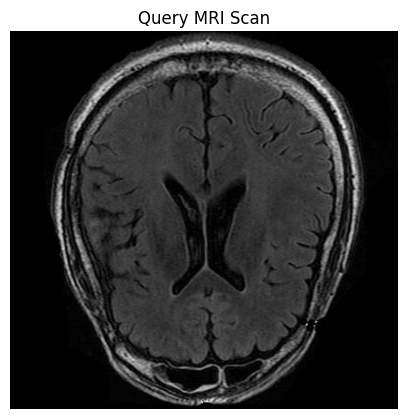

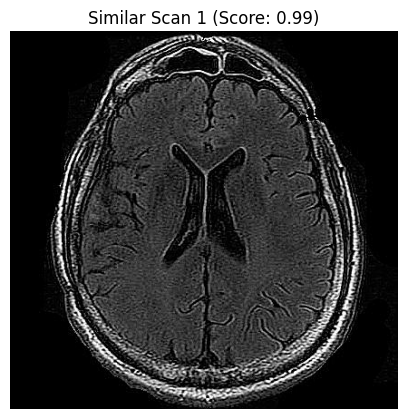

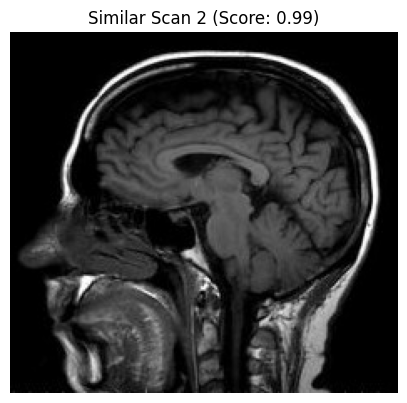

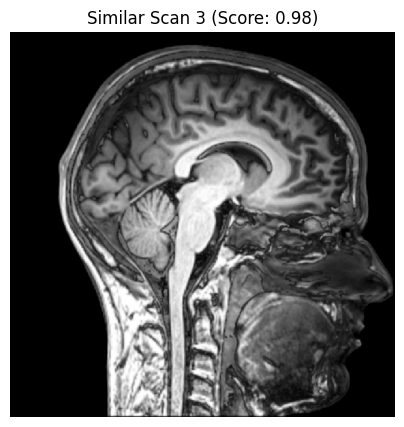

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from sklearn.metrics.pairwise import cosine_similarity

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --quiet
with zipfile.ZipFile('brain-tumor-mri-dataset.zip', 'r') as z:
    z.extractall('brain_mri')
print("Brain Tumor MRI dataset ready.")

mri_images = []
for root, _, files_list in os.walk('brain_mri'):
    for f in files_list:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            mri_images.append(os.path.join(root, f))

print(f"Total MRI images found: {len(mri_images)}")

def extract_gray_histogram(image, bins=256):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [bins], [0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

query_img = cv2.imread(mri_images[0])
query_features = extract_gray_histogram(query_img)

dataset_imgs = []
dataset_features = []
for path in mri_images[1:51]:
    img = cv2.imread(path)
    if img is None:
        continue
    dataset_imgs.append(img)
    dataset_features.append(extract_gray_histogram(img))

similarities = [cosine_similarity([query_features], [f])[0][0] for f in dataset_features]
ranked = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
plt.title('Query MRI Scan')
plt.axis('off')
plt.show()

top_k = 3
for i in range(min(top_k, len(dataset_imgs))):
    idx = ranked[i]
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(dataset_imgs[idx], cv2.COLOR_BGR2RGB))
    plt.title(f"Similar Scan {i+1} (Score: {similarities[idx]:.2f})")
    plt.axis('off')
    plt.show()